In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from scipy.io import loadmat
import os
from seawater import eos80
%matplotlib inline
%load_ext autoreload
%autoreload 2
# define the paths and filenames
import os, sys
sys.path.append(os.getcwd())
os.chdir("../..")
savedir = os.path.join(os.getcwd(),"DATA")
path = os.getcwd()
path = os.path.join(path,"DATA/SIOS21/")

/tmp/ipykernel_2464283/262492817.py:7: UserWarning: The seawater library is deprecated! Please use gsw instead.
  from seawater import eos80


### SBE 19plus supercooling and CT arm supercooling
This is to give an overview of the supercooling

In [2]:
## cast 1
# maybe do this later, because the upcast measurements didn't make it to the surface
# cast 2
# cast 3
ds_casts = xr.open_dataset(path+"Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FbestALCT_cast2_3_SC.nc", engine="netcdf4")
# CT arm
ds_CTarm = xr.open_dataset(path+"Ant2021/Ant2021CT/CT_data_small.nc", engine="netcdf4")

In [3]:
# find supercoolings at 10m depth for CTD's
# cast 2
casts_10m = ds_casts.where((np.round(ds_casts.Pressure_dbar,1)==10) & (ds_casts.SC>0))
# cast 3
time_casts =  [pd.to_datetime('2021-11-03 01:12:00', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-03 01:23:00', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-03 01:39:00', format='%Y-%m-%d %H:%M:%S')]

start_time = time_casts[0]
mid_time = time_casts[1]
end_time = time_casts[2]

ds_sel = ds_casts.sel(time=slice(start_time, end_time))

In [5]:
ds_adcp = xr.open_dataset(os.path.join(path,"adcp_data_and_analysis_lars_smedsrud/Nortek_ADCP_currents_Oct20_to_Nov4_avgd_cal.nc"))

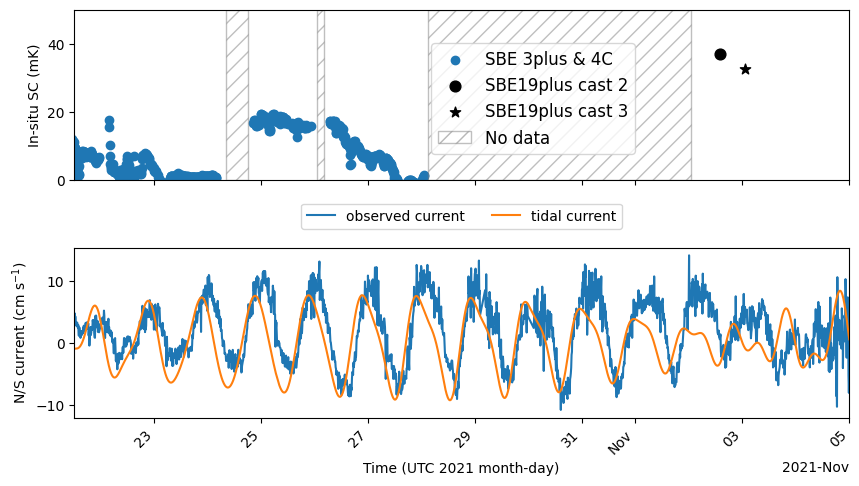

In [6]:
import matplotlib.dates as mdates
fig, (ax, ax2) = plt.subplots(ncols=1, nrows=2, figsize=(10, 5.3), sharex=True)

# Plot data on the first subplot
ax.scatter(ds_CTarm.time, ds_CTarm.SC, label="SBE 3plus & 4C")
ax.scatter(casts_10m.time.mean(), casts_10m.SC.mean(skipna=True), color="black", label="SBE19plus cast 2", s=60, marker="o")
ax.scatter(ds_sel.where((np.round(ds_casts.Pressure_dbar, 1) == 10) & (ds_casts.SC > 0)).time.mean(),
           ds_sel.where((np.round(ds_casts.Pressure_dbar, 1) == 10) & (ds_casts.SC > 0)).SC.mean(skipna=True),
           color="black", label="SBE19plus cast 3", s=60, marker="*")

# Set y-limits for the first subplot
ax.set_ylim([0, 50])

# Add hatching for specific time intervals
ax.axvspan(np.datetime64("2021-10-24T08:00"), np.datetime64("2021-10-24T18:00"), 
           facecolor='none', edgecolor='gray', hatch='//', alpha=0.5)
ax.axvspan(np.datetime64("2021-10-26T01:00"), np.datetime64("2021-10-26T04:00"), 
           facecolor='none', edgecolor='gray', hatch='//', alpha=0.5)
ax.axvspan(np.datetime64("2021-10-28T03:00"), np.datetime64("2021-11-02T01:00"), 
           facecolor='none', edgecolor='gray', hatch='//', alpha=0.5, label="No data")
ax.set_xticks([])

# Adjust legend for the first subplot
ax.legend(loc="upper left", bbox_to_anchor=(0.45, 0.85), fontsize=12, frameon=True)
plt.subplots_adjust(hspace=0.4)  # Increase spacing between subplots
# Set major ticks to every day and format them as Month-Day for the second subplot
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))

# Plot data on the second subplot
ds_adcp.v.plot(ax=ax2, label="observed current")
ds_adcp.tide_v.plot(ax=ax2, label="tidal current")

plt.xticks(rotation=45, ha="right")

# Labels and legend for the second subplot
ax2.set_xlabel("Time (UTC 2021 month-day)")
ax2.set_ylabel(r"N/S current (cm s$^{-1}$)")
ax.set_ylabel("In-situ SC (mK)")
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=2, frameon=True)
plt.rcParams['font.size'] = 16

# Set x-limits for both subplots
ax.set_xlim([np.datetime64("2021-10-21T12:00"), np.datetime64("2021-11-05T00:00")])

# Save the figure
fig.savefig(savedir+"/SC_CT_CTD.png", 
            dpi=300, bbox_inches="tight")

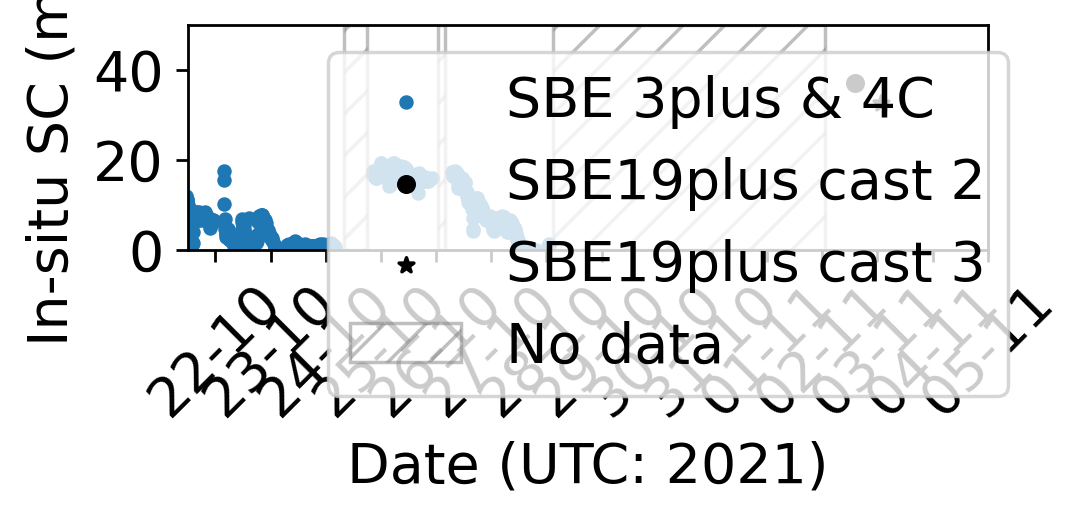

In [7]:
from mpl_toolkits.axes_grid1 import Divider, Size
# --- Figure & axes layout using Divider ---
fig = plt.figure(figsize=(4, 1.5), dpi=250)  # shorter figure; avoid constrained_layout with Divider

# Horizontal sizes: left pad, main width, right pad
h = [Size.Fixed(0.5), Size.Fixed(3.2), Size.Fixed(0.3)]

# Vertical sizes (bottom-to-top): bottom pad, MAIN plot, top pad
v = [Size.Fixed(0.45), Size.Fixed(0.90), Size.Fixed(0.15)]

divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)

# Main image axis
ax = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=1, ny=1))


# Plot data on the first subplot
ax.scatter(ds_CTarm.time, ds_CTarm.SC, label="SBE 3plus & 4C", s=10)
ax.scatter(casts_10m.time.mean(), casts_10m.SC.mean(skipna=True), color="black", label="SBE19plus cast 2", s=20, marker="o")
ax.scatter(ds_sel.where((np.round(ds_casts.Pressure_dbar, 1) == 10) & (ds_casts.SC > 0)).time.mean(),
           ds_sel.where((np.round(ds_casts.Pressure_dbar, 1) == 10) & (ds_casts.SC > 0)).SC.mean(skipna=True),
           color="black", label="SBE19plus cast 3", s=20, marker="*")

# Set y-limits for the first subplot
ax.set_ylim([0, 50])

# Add hatching for specific time intervals
ax.axvspan(np.datetime64("2021-10-24T08:00"), np.datetime64("2021-10-24T18:00"), 
           facecolor='none', edgecolor='gray', hatch='//', alpha=0.5)
ax.axvspan(np.datetime64("2021-10-26T01:00"), np.datetime64("2021-10-26T04:00"), 
           facecolor='none', edgecolor='gray', hatch='//', alpha=0.5)
ax.axvspan(np.datetime64("2021-10-28T03:00"), np.datetime64("2021-11-02T01:00"), 
           facecolor='none', edgecolor='gray', hatch='//', alpha=0.5, label="No data")

# Labels and legend for the second subplot
ax.set_xlabel("Time (UTC 2021 month-day)")
ax.set_ylabel("In-situ SC (mK)")
ax.legend(loc='upper center', bbox_to_anchor=(0.6, 1.), ncol=1, frameon=True)

# Set date format to dd-mm
date_format = mdates.DateFormatter("%d-%m")
ax.xaxis.set_major_formatter(date_format)
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=45)
ax.set_xlim([np.datetime64("2021-10-21T12:00"), np.datetime64("2021-11-05T00:00")])
ax.set_xlabel("Date (UTC: 2021)")

# ax.legend(loc="best")
plt.rcParams.update({'font.size': 7})
plt.show()

fig.savefig("/home/nina/REPORT/Constraining_the_origin_of_frazil/figures/SC_CT_CTD.png", 
            dpi=300, bbox_inches="tight")

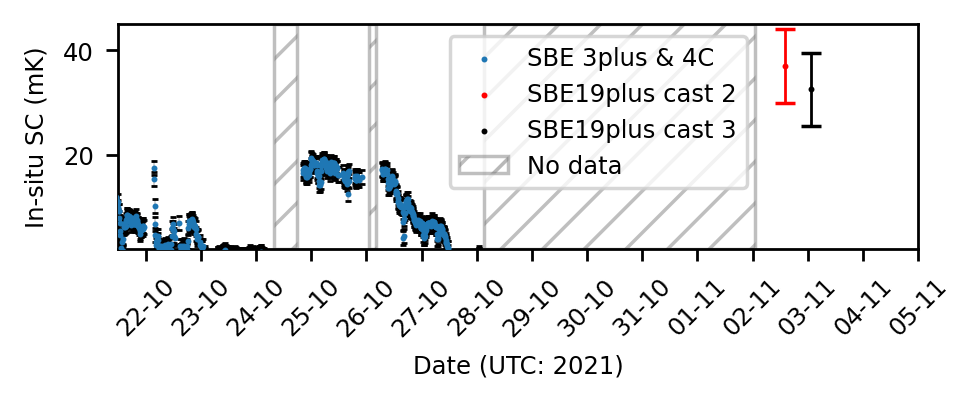

In [8]:
# --- Relative error (1-sigma) from your sensitivity analysis ---
rel_err_Tf = 0.0006343575553701701  # FPT error from simulations EOS80 (supercooling_uncertainty)
# Instrument 1-sigma uncertainties:
delta_t = 4 # months; calibration date CT 30 June 2021
err_T90_3plus = 0.0001 + delta_t * (1/6) * 0.0001   # deg C (SBE 3plus data sheet)
err_T90_19plus = 0.005 + delta_t * 0.0002   # deg C (SBE 19plus data sheet)

err_CT = rel_err_Tf * abs(ds_CTarm.fp) + err_T90_3plus
err_CTD10m_cast2 = rel_err_Tf * abs(casts_10m.fp.mean(skipna=True)) + err_T90_19plus
err_CTD10m_cast3 = rel_err_Tf * abs(ds_sel.where((np.round(ds_casts.Pressure_dbar, 1) == 10) & (ds_casts.SC > 0)).fp.mean(skipna=True)) + err_T90_19plus

# --- Figure & axes layout using Divider ---
fig = plt.figure(figsize=(4, 1.5), dpi=250)  # shorter figure; avoid constrained_layout with Divider

# Horizontal sizes: left pad, main width, right pad
h = [Size.Fixed(0.5), Size.Fixed(3.2), Size.Fixed(0.3)]

# Vertical sizes (bottom-to-top): bottom pad, MAIN plot, top pad
v = [Size.Fixed(0.45), Size.Fixed(0.90), Size.Fixed(0.15)]

divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)

# Main image axis
ax = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=1, ny=1))



# Align first
err_CT_aligned = err_CT.reindex_like(ds_CTarm.SC)

order = np.argsort(ds_CTarm.time.values)
t  = ds_CTarm.time.values[order]
SC = ds_CTarm.SC.values[order]
yerr = np.asarray(err_CT_aligned.values[order]) * 1e3

valid = np.isfinite(t) & np.isfinite(SC) & np.isfinite(yerr)

# Mask invalid
SC_m   = np.ma.array(SC,   mask=~valid)
yerr_m = np.ma.array(yerr, mask=~valid)

ax.scatter(ds_CTarm.time, ds_CTarm.SC, label="SBE 3plus & 4C", s=2, marker=".", color="tab:blue", zorder=3)
ax.errorbar(
    t, SC_m, yerr=yerr_m,
    fmt="none",
    color="black",
    ecolor="black",
    elinewidth=0.1,
    capsize=1,
    capthick=0.8,
    zorder=2,
)

ax.scatter(casts_10m.time.mean(), casts_10m.SC.mean(skipna=True), color="red", label="SBE19plus cast 2", s=2, marker=".")
ax.errorbar(casts_10m.time.mean(), casts_10m.SC.mean(skipna=True), 
            xerr = None,
            yerr = err_CTD10m_cast2*1e3,
            fmt = "none",
            color="red",
            elinewidth = 0.8,
            capsize = 3,
            zorder = 2
            )
ax.scatter(ds_sel.where((np.round(ds_casts.Pressure_dbar, 1) == 10) & (ds_casts.SC > 0)).time.mean(),
           ds_sel.where((np.round(ds_casts.Pressure_dbar, 1) == 10) & (ds_casts.SC > 0)).SC.mean(skipna=True),
           color="black", label="SBE19plus cast 3", s=2, marker=".")
ax.errorbar(ds_sel.where((np.round(ds_casts.Pressure_dbar, 1) == 10) & (ds_casts.SC > 0)).time.mean(),
           ds_sel.where((np.round(ds_casts.Pressure_dbar, 1) == 10) & (ds_casts.SC > 0)).SC.mean(skipna=True),
            xerr = None,
            yerr = err_CTD10m_cast3*1e3,
            fmt = "none",
            color="black",
            elinewidth = 0.8,
            capsize = 3,
            zorder = 2
            )
# Set y-limits for the first subplot
ax.set_ylim([2, 45])

# Add hatching for specific time intervals
ax.axvspan(np.datetime64("2021-10-24T08:00"), np.datetime64("2021-10-24T18:00"), 
           facecolor='none', edgecolor='gray', hatch='//', alpha=0.5)
ax.axvspan(np.datetime64("2021-10-26T01:00"), np.datetime64("2021-10-26T04:00"), 
           facecolor='none', edgecolor='gray', hatch='//', alpha=0.5)
ax.axvspan(np.datetime64("2021-10-28T03:00"), np.datetime64("2021-11-02T01:00"), 
           facecolor='none', edgecolor='gray', hatch='//', alpha=0.5, label="No data")

# Labels and legend for the second subplot
ax.set_xlabel("Time (UTC 2021 month-day)")
ax.set_ylabel("In-situ SC (mK)")
ax.legend(loc='upper center', bbox_to_anchor=(0.6, 1.), ncol=1, frameon=True)

# Set date format to dd-mm
date_format = mdates.DateFormatter("%d-%m")
ax.xaxis.set_major_formatter(date_format)
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=45)
ax.set_xlim([np.datetime64("2021-10-21T12:00"), np.datetime64("2021-11-05T00:00")])
ax.set_xlabel("Date (UTC: 2021)")

# ax.legend(loc="best")
plt.rcParams.update({'font.size': 7})

fig.savefig(os.path.join(savedir,"SC_CT_CTD.png"), 
            dpi=300, bbox_inches="tight")

In [10]:
casts_10m.SC.mean(skipna=True)

<xarray.DataArray 'SC' ()> Size: 8B
array(36.99787664)

In [9]:
ds_sel.where((np.round(ds_casts.Pressure_dbar, 1) == 10) & (ds_casts.SC > 0)).SC.mean(skipna=True)

<xarray.DataArray 'SC' ()> Size: 8B
array(32.53748178)

(np.float64(18921.5), np.float64(18936.0))

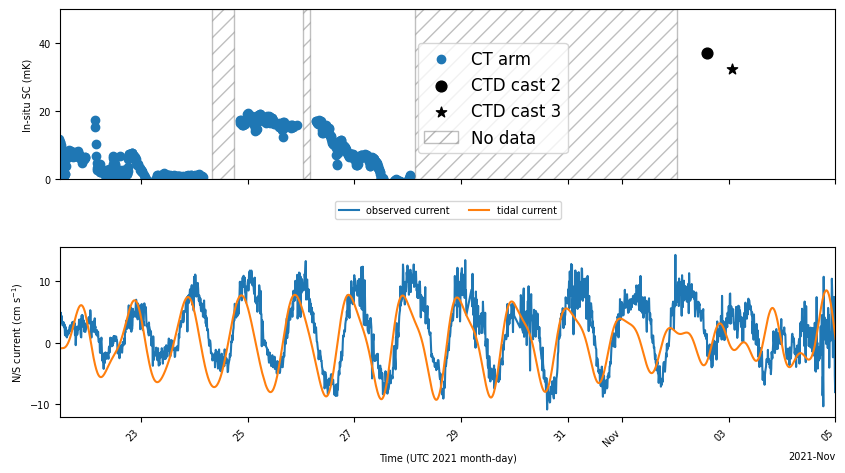

In [11]:
import matplotlib.dates as mdates
fig, (ax, ax2) = plt.subplots(ncols=1, nrows=2, figsize=(10, 5.3), sharex=True)

# Plot data on the first subplot
ax.scatter(ds_CTarm.time, ds_CTarm.SC, label="CT arm")
ax.scatter(casts_10m.time.mean(), casts_10m.SC.mean(skipna=True), color="black", label="CTD cast 2", s=60, marker="o")
ax.scatter(ds_sel.where((np.round(ds_casts.Pressure_dbar, 1) == 10) & (ds_casts.SC > 0)).time.mean(),
           ds_sel.where((np.round(ds_casts.Pressure_dbar, 1) == 10) & (ds_casts.SC > 0)).SC.mean(skipna=True),
           color="black", label="CTD cast 3", s=60, marker="*")

# Set y-limits for the first subplot
ax.set_ylim([0, 50])

# Add hatching for specific time intervals
ax.axvspan(np.datetime64("2021-10-24T08:00"), np.datetime64("2021-10-24T18:00"), 
           facecolor='none', edgecolor='gray', hatch='//', alpha=0.5)
ax.axvspan(np.datetime64("2021-10-26T01:00"), np.datetime64("2021-10-26T04:00"), 
           facecolor='none', edgecolor='gray', hatch='//', alpha=0.5)
ax.axvspan(np.datetime64("2021-10-28T03:00"), np.datetime64("2021-11-02T01:00"), 
           facecolor='none', edgecolor='gray', hatch='//', alpha=0.5, label="No data")
ax.set_xticks([])

# Adjust legend for the first subplot
ax.legend(loc="upper left", bbox_to_anchor=(0.45, 0.85), fontsize=12, frameon=True)
plt.subplots_adjust(hspace=0.4)  # Increase spacing between subplots
# Set major ticks to every day and format them as Month-Day for the second subplot
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))

# Plot data on the second subplot
ds_adcp.v.plot(ax=ax2, label="observed current")
ds_adcp.tide_v.plot(ax=ax2, label="tidal current")

plt.xticks(rotation=45, ha="right")

# Labels and legend for the second subplot
ax2.set_xlabel("Time (UTC 2021 month-day)")
ax2.set_ylabel(r"N/S current (cm s$^{-1}$)")
ax.set_ylabel("In-situ SC (mK)")
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=2, frameon=True)
plt.rcParams['font.size'] = 16

# Set x-limits for both subplots
ax.set_xlim([np.datetime64("2021-10-21T12:00"), np.datetime64("2021-11-05T00:00")])